# 1) Libraries Installation


**Install packages**

In [2]:
install.packages(c("tidyverse", "tseries", "zoo", "caret", "keras", "tensorflow", "conflicted","xgboost","data.table","Metrics","ggplot2","readr","dplyr", "pROC","ROCR"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘sparsevctrs’, ‘prodlim’, ‘bitops’, ‘xts’, ‘TTR’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘timeDate’, ‘RcppTOML’, ‘here’, ‘png’, ‘gtools’, ‘caTools’, ‘quadprog’, ‘quantmod’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘recipes’, ‘reshape2’, ‘reticulate’, ‘tfruns’, ‘zeallot’, ‘config’, ‘tfautograph’, ‘gplots’




**Load Libraries**

In [3]:
library(tidyverse)   # For data manipulation and visualization
library(tseries)     # For time series analysis (KPSS test)
library(zoo)         # For missing data handling
library(caret)       # For machine learning
library(keras)       # For deep learning
library(tensorflow)  # For deep learning backend
library(conflicted)  # To manage function conflicts
library(googledrive) #for accessing Goodgle Drive
library(readr)
library(dplyr)
library(pROC)
library(ROCR)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift



Attaching package: ‘tensorflow’


The following object is masked from ‘package:caret’:

    train


Type 'citation("pROC")' for a ci

**Set Conflict Preferences**

In [4]:
#ensure that dplyr::filter() and dplyr::lag() are always used instead of stats::filter() and stats::lag()
conflict_prefer("filter", "dplyr")
conflict_prefer("lag", "dplyr")

[conflicted] Will prefer dplyr::filter over any other package.
[conflicted] Will prefer dplyr::lag over any other package.


# 2) Data Handling


## Read Data

**Enable Google Drive Access**

In [5]:
drive_auth()

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=07502eea96b0ed1c508da6b2dc69ed58&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQVNWZ2kzS3lYUFZ2V1F1dFhaTEdQbDIzUzFRZ1ZwMGFLQ3NJTU50MDZheURRZl9yMnRwNjBDRWp0NWtxMERhY0NjdS1QdyIsInN0YXRlIjoiMDc1MDJlZWE5NmIwZWQxYzUwOGRhNmIyZGM2OWVkNTgifQ==


**Read the CSV File**

In [6]:
# Define file paths in Google Drive (update if needed)
file_path_quarterly <- "databusters/Quarterly Data.csv"
file_path_monthly <- "databusters/Monthly Data.csv"

# Download files from Google Drive
drive_download(file_path_quarterly, path = "Quarterly_Data.csv", overwrite = TRUE)
drive_download(file_path_monthly, path = "Monthly_Data.csv", overwrite = TRUE)

# Read CSV files
quarterly_data <- read_csv("Quarterly_Data.csv")
monthly_data <- read_csv("Monthly_Data.csv")

File downloaded:

• Quarterly Data.csv <id: 1EyYlmimVB0Z-wZzf1qY94jMobdud-cH6>

Saved locally as:

• Quarterly_Data.csv

File downloaded:

• Monthly Data.csv <id: 1CZAHi0H83ReE4pLNG614r4KxrCNgMm7H>

Saved locally as:

• Monthly_Data.csv

Rows: 265 Columns: 246
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): sasdate
dbl (245): GDPC1, PCECC96, PCDGx, PCESVx, PCNDx, GPDIC1, FPIx, Y033RC1Q027SB...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 792 Columns: 127
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (1): sasdate
dbl (126): RPI, W875RX1, DPCERA3M086SBEA, CMRMTSPLx, RETAILx, INDPRO, IPFPNS...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## Exploratory Data Analysis (EDA)

**Data Preprocessing**

In [7]:
# Remove metadata rows
quarterly_data <- quarterly_data[-c(1,2), ]
monthly_data <- monthly_data[-1, ]

# Convert date columns to Date format
quarterly_data$sasdate <- as.Date(quarterly_data$sasdate, format="%m/%d/%Y")
monthly_data$sasdate <- as.Date(monthly_data$sasdate, format="%m/%d/%Y")

# Convert numeric columns
quarterly_data[, -1] <- lapply(quarterly_data[, -1], as.numeric)
monthly_data[, -1] <- lapply(monthly_data[, -1], as.numeric)

# Remove duplicate rows
quarterly_data <- quarterly_data %>% distinct()
monthly_data <- monthly_data %>% distinct()

# Handle missing values using forward fill
quarterly_data <- quarterly_data %>% fill(everything(), .direction = "down")
monthly_data <- monthly_data %>% fill(everything(), .direction = "down")

# Save processed datasets
write_csv(quarterly_data, "Processed_Quarterly_Data.csv")
write_csv(monthly_data, "Processed_Monthly_Data.csv")

# Output summary of datasets
summary(quarterly_data)
summary(monthly_data)

    sasdate               GDPC1          PCECC96          PCDGx        
 Min.   :1959-03-01   Min.   : 3352   Min.   : 2039   Min.   :  66.72  
 1st Qu.:1975-07-17   1st Qu.: 6137   1st Qu.: 3842   1st Qu.: 175.51  
 Median :1991-12-01   Median :10115   Median : 6414   Median : 339.00  
 Mean   :1991-12-01   Mean   :11447   Mean   : 7502   Mean   : 596.79  
 3rd Qu.:2008-04-16   3rd Qu.:16572   3rd Qu.:11171   3rd Qu.: 929.25  
 Max.   :2024-09-01   Max.   :23400   Max.   :16113   Max.   :2059.97  
                                                                       
     PCESVx          PCNDx            GPDIC1            FPIx       
 Min.   : 1374   Min.   : 689.1   Min.   : 327.0   Min.   : 357.0  
 1st Qu.: 2791   1st Qu.:1075.9   1st Qu.: 774.9   1st Qu.: 769.2  
 Median : 4844   Median :1537.6   Median :1304.6   Median :1290.6  
 Mean   : 5282   Mean   :1741.8   Mean   :1762.1   Mean   :1745.0  
 3rd Qu.: 7938   3rd Qu.:2386.3   3rd Qu.:2640.3   3rd Qu.:2624.5  
 Max.   :10656  

    sasdate                RPI           W875RX1      DPCERA3M086SBEA 
 Min.   :1959-01-01   Min.   : 2584   Min.   : 2426   Min.   : 15.19  
 1st Qu.:1975-06-16   1st Qu.: 5147   1st Qu.: 4573   1st Qu.: 28.98  
 Median :1991-12-01   Median : 8366   Median : 7263   Median : 48.36  
 Mean   :1991-12-01   Mean   : 9559   Mean   : 8141   Mean   : 56.61  
 3rd Qu.:2008-05-16   3rd Qu.:13770   3rd Qu.:11451   3rd Qu.: 84.21  
 Max.   :2024-11-01   Max.   :22850   Max.   :16434   Max.   :122.17  
                                                                      
   CMRMTSPLx          RETAILx           INDPRO          IPFPNSS      
 Min.   : 265935   Min.   : 18236   Min.   : 21.96   Min.   : 23.39  
 1st Qu.: 488563   1st Qu.: 51073   1st Qu.: 44.96   1st Qu.: 47.07  
 Median : 720271   Median :162113   Median : 62.64   Median : 71.53  
 Mean   : 824358   Mean   :222791   Mean   : 67.64   Mean   : 71.89  
 3rd Qu.:1179064   3rd Qu.:358170   3rd Qu.: 95.39   3rd Qu.: 99.28  
 Max.   :154

**Stationarity Check & Transformation**

Monthly Data

In [8]:
# Load dataset
df_monthly <- read_csv("Processed_Monthly_Data.csv")

# Convert date column to Date format
df_monthly$sasdate <- as.Date(df_monthly$sasdate)

# Select numeric columns
num_cols <- names(df_monthly)[sapply(df_monthly, is.numeric)]

# Apply first differencing
df_monthly_diff <- df_monthly %>%
  arrange(sasdate) %>%
  mutate(across(all_of(num_cols), ~ . - lag(.), .names = "diff_{col}")) %>%
  drop_na()

# Perform KPSS test for stationarity
variables_to_test <- c("diff_INDPRO", "diff_UNRATE", "diff_DPCERA3M086SBEA", "diff_RETAILx", "diff_BUSINVx")

kpss_results_monthly <- map(variables_to_test, ~ kpss.test(df_monthly_diff[[.]], null = "Level")$p.value)
names(kpss_results_monthly) <- variables_to_test
print(kpss_results_monthly)

# Save transformed data
write_csv(df_monthly_diff, "Stabilised_Monthly_Data.csv")


Rows: 791 Columns: 127
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (126): RPI, W875RX1, DPCERA3M086SBEA, CMRMTSPLx, RETAILx, INDPRO, IPFPN...
date   (1): sasdate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in kpss.test(df_monthly_diff[[.]], null = "Level"):
“p-value greater than printed p-value”
Warning message in kpss.test(df_monthly_diff[[.]], null = "Level"):
“p-value greater than printed p-value”
Warning message in kpss.test(df_monthly_diff[[.]], null = "Level"):
“p-value greater than printed p-value”


$diff_INDPRO
[1] 0.1

$diff_UNRATE
[1] 0.1

$diff_DPCERA3M086SBEA
[1] 0.1

$diff_RETAILx
[1] 0.0726613

$diff_BUSINVx
[1] 0.08708524



Quarterly Data

In [9]:
# Load dataset
df_quarterly <- read_csv("Processed_Quarterly_Data.csv")

# Convert date column
df_quarterly$sasdate <- as.Date(df_quarterly$sasdate, format="%Y-%m-%d")

# Handle missing values using forward and backward fill
df_quarterly <- df_quarterly %>%
  mutate(across(everything(), ~ na.locf(., na.rm = FALSE))) %>%
  mutate(across(everything(), ~ na.locf(., na.rm = FALSE, fromLast = TRUE)))

# Apply first differencing for stationarity
selected_columns <- c("GDPC1", "S.P.500", "CPIAUCSL", "BUSINVx", "INDPRO")
selected_columns <- selected_columns[selected_columns %in% colnames(df_quarterly)]

df_quarterly_diff <- df_quarterly %>%
  arrange(sasdate) %>%
  mutate(across(all_of(selected_columns), ~ . - lag(.), .names = "diff_{col}")) %>%
  drop_na()

# Perform KPSS test
variables_to_test <- paste0("diff_", selected_columns)
kpss_results_quarterly <- map(variables_to_test, ~ kpss.test(df_quarterly_diff[[.]], null = "Level")$p.value)
names(kpss_results_quarterly) <- variables_to_test
print(kpss_results_quarterly)

# Apply second differencing if needed
df_quarterly_diff2 <- df_quarterly_diff %>%
  mutate(across(all_of(variables_to_test), ~ . - lag(.), .names = "diff2_{col}")) %>%
  drop_na()

# Re-run KPSS test on second differencing
kpss_results_quarterly2 <- map(paste0("diff2_", variables_to_test), ~ kpss.test(df_quarterly_diff2[[.]], null = "Level")$p.value)
names(kpss_results_quarterly2) <- paste0("diff2_", variables_to_test)
print(kpss_results_quarterly2)

# Save transformed data
write_csv(df_quarterly_diff2, "Stabilised_Quarterly_Data.csv")


Rows: 263 Columns: 246
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (245): GDPC1, PCECC96, PCDGx, PCESVx, PCNDx, GPDIC1, FPIx, Y033RC1Q027S...
date   (1): sasdate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in kpss.test(df_quarterly_diff[[.]], null = "Level"):
“p-value smaller than printed p-value”
Warning message in kpss.test(df_quarterly_diff[[.]], null = "Level"):
“p-value smaller than printed p-value”
Warning message in kpss.test(df_quarterly_diff[[.]], null = "Level"):
“p-value greater than printed p-value”


$diff_GDPC1
[1] 0.01

$diff_CPIAUCSL
[1] 0.01

$diff_BUSINVx
[1] 0.01566419

$diff_INDPRO
[1] 0.1



Warning message in kpss.test(df_quarterly_diff2[[.]], null = "Level"):
“p-value greater than printed p-value”
Warning message in kpss.test(df_quarterly_diff2[[.]], null = "Level"):
“p-value greater than printed p-value”
Warning message in kpss.test(df_quarterly_diff2[[.]], null = "Level"):
“p-value greater than printed p-value”
Warning message in kpss.test(df_quarterly_diff2[[.]], null = "Level"):
“p-value greater than printed p-value”


$diff2_diff_GDPC1
[1] 0.1

$diff2_diff_CPIAUCSL
[1] 0.1

$diff2_diff_BUSINVx
[1] 0.1

$diff2_diff_INDPRO
[1] 0.1



# 3）Model Training

### **Logistic Regression**

A) DATA PREPARATION

In [ ]:
df <- read_csv("Stabilised_Quarterly_Data.csv") %>%
  arrange(sasdate)
df$sasdate <- as.Date(df$sasdate)

# Define contraction flags separately for 1Q, 2Q, 4Q
# Example: 1 if next quarter's diff_GDPC1 < 0
df <- df %>%
  mutate(
    Contraction_1Q = ifelse(lead(diff_GDPC1,1) < 0, 1, 0),
    Contraction_2Q = ifelse(lead(diff_GDPC1,2) < 0, 1, 0),
    Contraction_4Q = ifelse(lead(diff_GDPC1,4) < 0, 1, 0)
  )

# Notice that near the end of the dataset, some rows can't see 4 quarters ahead,
# so 'Contraction_4Q' will be NA there; we want to keep those rows for 1Q/2Q usage.

# 1Q data frame: only remove rows where Contraction_1Q is NA
df_1Q <- df %>% filter(!is.na(Contraction_1Q))
# 2Q data frame
df_2Q <- df %>% filter(!is.na(Contraction_2Q))
# 4Q data frame
df_4Q <- df %>% filter(!is.na(Contraction_4Q))

# Suppose we use all differenced columns as predictors
pred_cols <- df %>%
  select(starts_with("diff_")) %>%
  names()

Rows: 259 Columns: 254
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (253): GDPC1, PCECC96, PCDGx, PCESVx, PCNDx, GPDIC1, FPIx, Y033RC1Q027S...
date   (1): sasdate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


B) TRAIN/TEST SPLIT & MODEL FITTING

In [ ]:
# We pick 2020 as the date cutoff. Everything before 2020 is train, after 2020 is test.
# This keeps 2024 data in the short-horizon frames (1Q/2Q) if it's available.

### 1Q HORIZON
df_1Q_train <- df_1Q %>% filter(sasdate <  "2020-01-01")
df_1Q_test  <- df_1Q %>% filter(sasdate >= "2020-01-01")

df_1Q_train$Contraction_1Q <- factor(df_1Q_train$Contraction_1Q, levels=c(0,1))
df_1Q_test$Contraction_1Q  <- factor(df_1Q_test$Contraction_1Q,  levels=c(0,1))

m1Q <- glm(
  Contraction_1Q ~ .,
  data = df_1Q_train[, c(pred_cols, "Contraction_1Q")],
  family = binomial
)

### 2Q HORIZON
df_2Q_train <- df_2Q %>% filter(sasdate <  "2020-01-01")
df_2Q_test  <- df_2Q %>% filter(sasdate >= "2020-01-01")

df_2Q_train$Contraction_2Q <- factor(df_2Q_train$Contraction_2Q, levels=c(0,1))
df_2Q_test$Contraction_2Q  <- factor(df_2Q_test$Contraction_2Q,  levels=c(0,1))

m2Q <- glm(
  Contraction_2Q ~ .,
  data = df_2Q_train[, c(pred_cols, "Contraction_2Q")],
  family = binomial
)

### 4Q HORIZON
# For 4Q, we lose final rows that can't see 4 quarters ahead,
# but 1Q and 2Q keep those 2024 observations if they're valid for shorter leads.
df_4Q_train <- df_4Q %>% filter(sasdate <  "2020-01-01")
df_4Q_test  <- df_4Q %>% filter(sasdate >= "2020-01-01")

df_4Q_train$Contraction_4Q <- factor(df_4Q_train$Contraction_4Q, levels=c(0,1))
df_4Q_test$Contraction_4Q  <- factor(df_4Q_test$Contraction_4Q,  levels=c(0,1))

m4Q <- glm(
  Contraction_4Q ~ .,
  data = df_4Q_train[, c(pred_cols, "Contraction_4Q")],
  family = binomial
)

C) EVALUATION


=== 1Q TEST ===


Setting levels: control = 1, case = 2

Setting direction: controls < cases



Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 13  1
         1  3  1
                                          
               Accuracy : 0.7778          
                 95% CI : (0.5236, 0.9359)
    No Information Rate : 0.8889          
    P-Value [Acc > NIR] : 0.9579          
                                          
                  Kappa : 0.2174          
                                          
 Mcnemar's Test P-Value : 0.6171          
                                          
            Sensitivity : 0.8125          
            Specificity : 0.5000          
         Pos Pred Value : 0.9286          
         Neg Pred Value : 0.2500          
             Prevalence : 0.8889          
         Detection Rate : 0.7222          
   Detection Prevalence : 0.7778          
      Balanced Accuracy : 0.6562          
                                          
       'Positive' Class : 0               
                                    

Setting levels: control = 1, case = 2

Setting direction: controls < cases



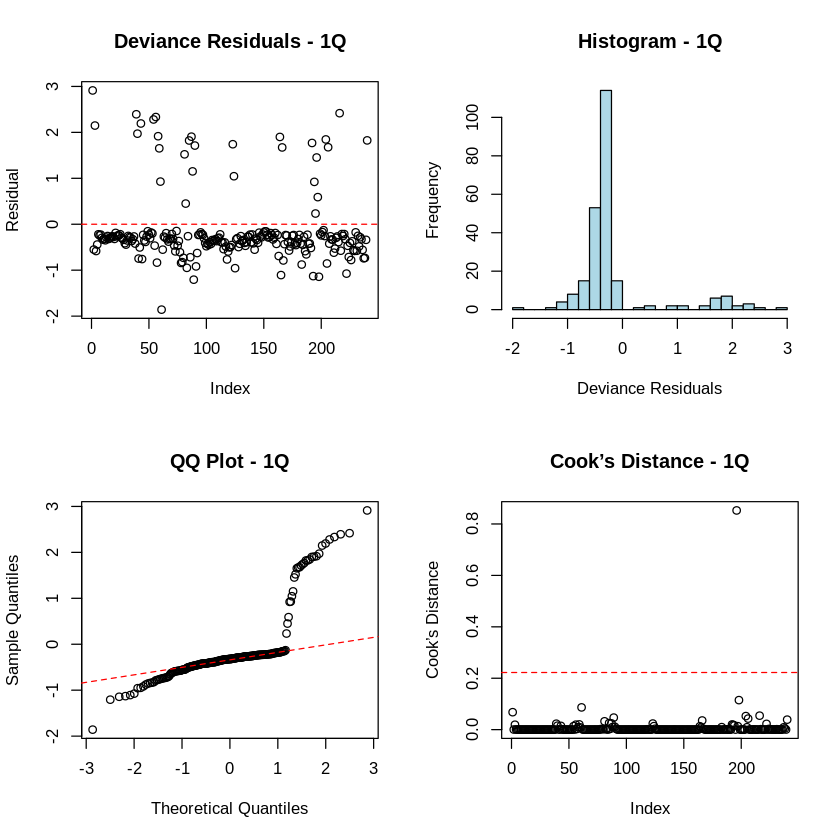

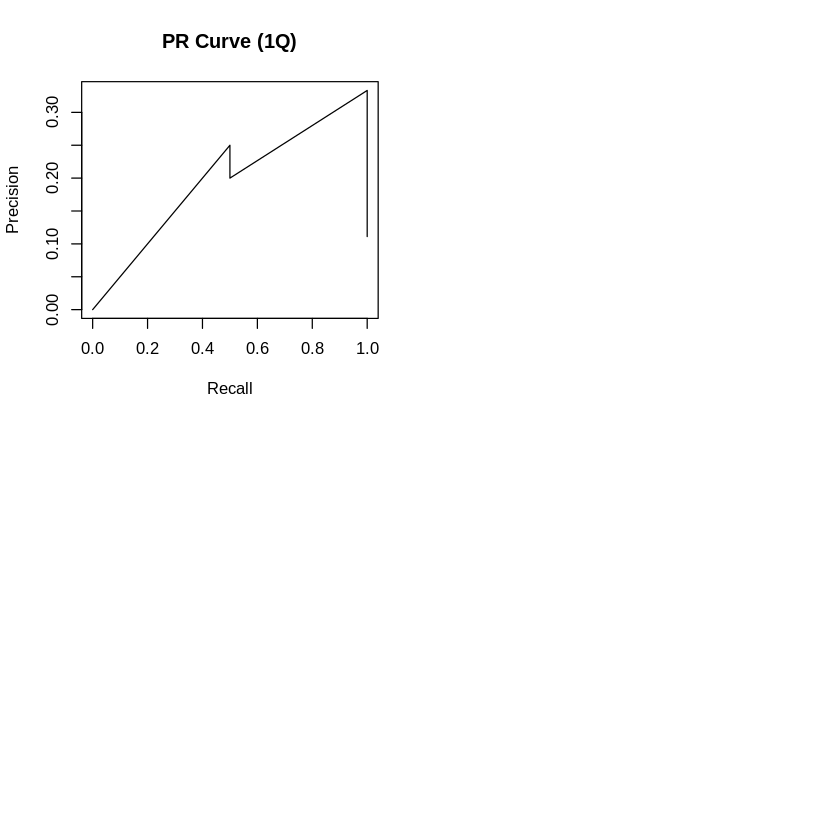

Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 12  1
         1  4  0
                                          
               Accuracy : 0.7059          
                 95% CI : (0.4404, 0.8969)
    No Information Rate : 0.9412          
    P-Value [Acc > NIR] : 0.9997          
                                          
                  Kappa : -0.1039         
                                          
 Mcnemar's Test P-Value : 0.3711          
                                          
            Sensitivity : 0.7500          
            Specificity : 0.0000          
         Pos Pred Value : 0.9231          
         Neg Pred Value : 0.0000          
             Prevalence : 0.9412          
         Detection Rate : 0.7059          
   Detection Prevalence : 0.7647          
      Balanced Accuracy : 0.3750          
                                          
       'Positive' Class : 0               
                                    

Setting levels: control = 1, case = 2

Setting direction: controls < cases



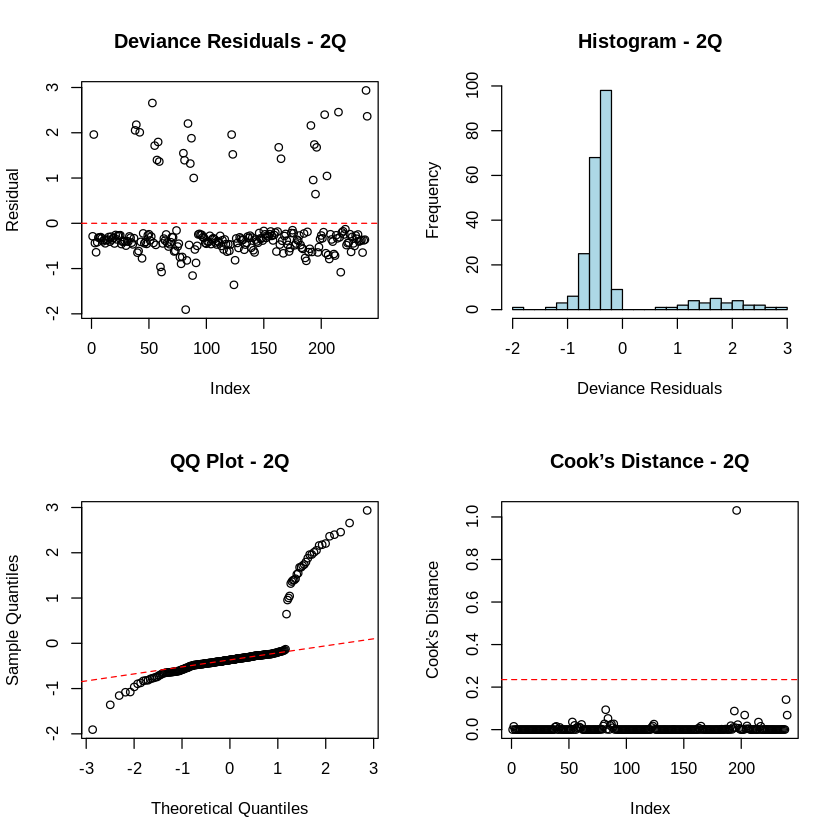

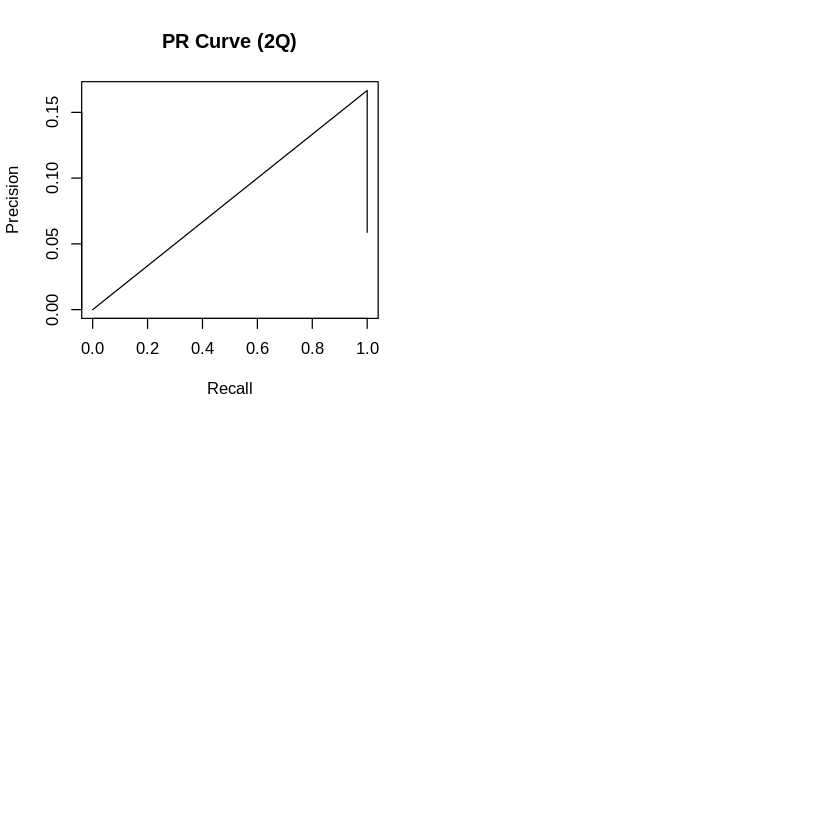

Confusion Matrix and Statistics

          Reference
Prediction 0 1
         0 8 1
         1 6 0
                                          
               Accuracy : 0.5333          
                 95% CI : (0.2659, 0.7873)
    No Information Rate : 0.9333          
    P-Value [Acc > NIR] : 1.0000          
                                          
                  Kappa : -0.129          
                                          
 Mcnemar's Test P-Value : 0.1306          
                                          
            Sensitivity : 0.5714          
            Specificity : 0.0000          
         Pos Pred Value : 0.8889          
         Neg Pred Value : 0.0000          
             Prevalence : 0.9333          
         Detection Rate : 0.5333          
   Detection Prevalence : 0.6000          
      Balanced Accuracy : 0.2857          
                                          
       'Positive' Class : 0               
                                          

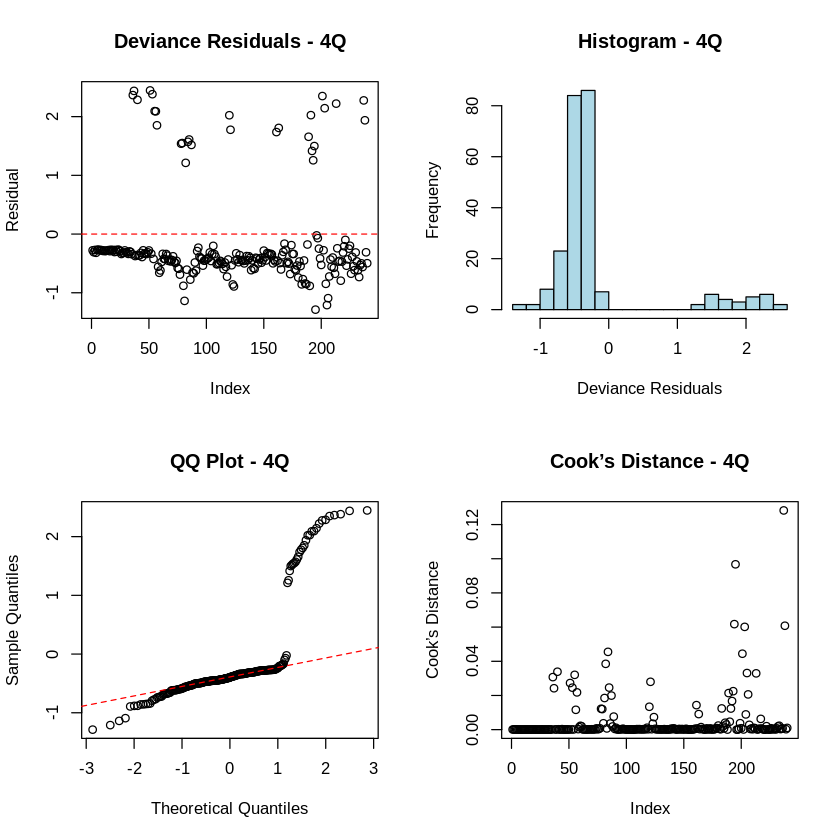

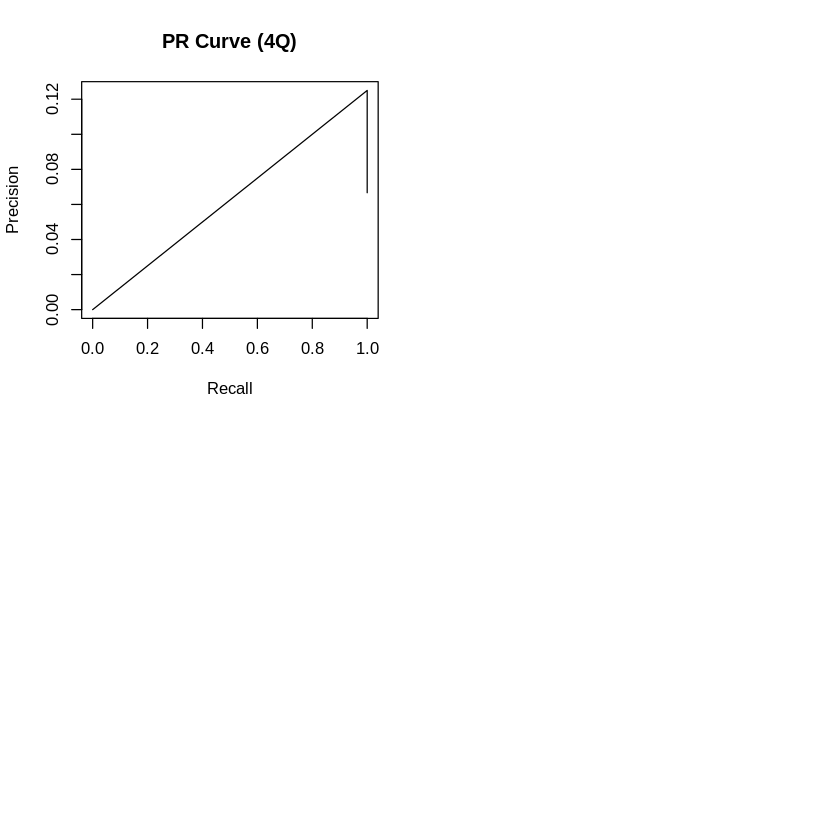

In [ ]:
# Define evaluation function
eval_horizon <- function(model, dataX, trueY, horizon) {
  p <- predict(model, newdata=dataX, type="response")
  c <- ifelse(p >= 0.5, 1, 0)
  cm <- confusionMatrix(factor(c, c(0,1)), trueY)
  rocobj <- roc(as.numeric(trueY), p)
  probj  <- prediction(p, as.numeric(trueY))

  # Calculate residuals
  dev_resid <- residuals(model, type="deviance")  # Deviance residuals
  pearson_resid <- residuals(model, type="pearson")  # Pearson residuals

  # Plot residuals
  par(mfrow=c(2,2))  # Arrange plots in 2x2 layout

  # Deviance Residual Plot
  plot(dev_resid, main=paste("Deviance Residuals -", horizon), ylab="Residual", xlab="Index")
  abline(h=0, col="red", lty=2)

  # Histogram of Deviance Residuals
  hist(dev_resid, main=paste("Histogram -", horizon), xlab="Deviance Residuals", breaks=20, col="lightblue")

  # QQ Plot to check normality
  qqnorm(dev_resid, main=paste("QQ Plot -", horizon))
  qqline(dev_resid, col="red", lty=2)

  # Influence Plot
  plot(cooks.distance(model), main=paste("Cook’s Distance -", horizon), xlab="Index", ylab="Cook’s Distance")
  abline(h=4/(nrow(dataX)), col="red", lty=2)  # Threshold for high leverage

  return(list(CM=cm, AUC=auc(rocobj), PR=performance(probj,"prec","rec")))
}

# Evaluate logistic model's performance
cat("\n=== 1Q TEST ===\n")
if(nrow(df_1Q_test)>0) {
  X_1Q_test <- df_1Q_test[, pred_cols, drop=FALSE]
  r1Q <- eval_horizon(m1Q, X_1Q_test, df_1Q_test$Contraction_1Q, "1Q")
  print(r1Q$CM)
  cat("AUC:", r1Q$AUC, "\n")
  plot(r1Q$PR, main="PR Curve (1Q)")
} else cat("No 1Q test data.\n")

cat("\n=== 2Q TEST ===\n")
if(nrow(df_2Q_test)>0) {
  X_2Q_test <- df_2Q_test[, pred_cols, drop=FALSE]
  r2Q <- eval_horizon(m2Q, X_2Q_test, df_2Q_test$Contraction_2Q, "2Q")
  print(r2Q$CM)
  cat("AUC:", r2Q$AUC, "\n")
  plot(r2Q$PR, main="PR Curve (2Q)")
} else cat("No 2Q test data.\n")

cat("\n=== 4Q TEST ===\n")
if(nrow(df_4Q_test)>0) {
  X_4Q_test <- df_4Q_test[, pred_cols, drop=FALSE]
  r4Q <- eval_horizon(m4Q, X_4Q_test, df_4Q_test$Contraction_4Q, "4Q")
  print(r4Q$CM)
  cat("AUC:", r4Q$AUC, "\n")
  plot(r4Q$PR, main="PR Curve (4Q)")
} else cat("No 4Q test data.\n")

D) FORECAST

In [ ]:
# We pick the maximum date in each horizon's dataset.

last_date_1q <- max(df_1Q$sasdate)
last_date_2q <- max(df_2Q$sasdate)
last_date_4q <- max(df_4Q$sasdate)

last_obs_1Q <- df_1Q %>% filter(sasdate == last_date_1q)
last_obs_2Q <- df_2Q %>% filter(sasdate == last_date_2q)
last_obs_4Q <- df_4Q %>% filter(sasdate == last_date_4q)

# -----------------------
# 1Q FORECAST
# -----------------------
if(nrow(last_obs_1Q) > 0) {
  feats <- last_obs_1Q[, pred_cols, drop=FALSE]
  p     <- predict(m1Q, newdata=feats, type="response")
  cat("\nForecast 1Q =>", ifelse(p >= 0.5, "YES", "NO"),
      "(Prob:", round(p,4), ")\n")
} else {
  cat("\nNo last row found for 1Q horizon.\n")
}

# -----------------------
# 2Q FORECAST
# -----------------------
if(nrow(last_obs_2Q) > 0) {
  feats <- last_obs_2Q[, pred_cols, drop=FALSE]
  p     <- predict(m2Q, newdata=feats, type="response")
  cat("Forecast 2Q =>", ifelse(p >= 0.5, "YES", "NO"),
      "(Prob:", round(p,4), ")\n")
} else {
  cat("No last row found for 2Q horizon.\n")
}

# -----------------------
# 4Q FORECAST
# -----------------------
if(nrow(last_obs_4Q) > 0) {
  feats <- last_obs_4Q[, pred_cols, drop=FALSE]
  p     <- predict(m4Q, newdata=feats, type="response")
  cat("Forecast 4Q =>", ifelse(p >= 0.5, "YES", "NO"),
      "(Prob:", round(p,4), ")\n")
} else {
  cat("No last row found for 4Q horizon.\n")
}


Forecast 1Q => NO (Prob: 0.101 )
Forecast 2Q => NO (Prob: 0.2089 )
Forecast 4Q => NO (Prob: 0.1958 )


### **XGboost**

choose features for modelling based on accuracy

In [ ]:
# Load necessary libraries
library(xgboost)
library(data.table)
library(lubridate)
library(Metrics)
library(ggplot2)

# Load the dataset
data <- fread("data/Stabilised_Quarterly_Data.csv")

data$sasdate <- as.Date(data$sasdate, format="%Y/%m/%d")

# Split data into training (up to 2022) and test set (2023-2024)
train_data <- data[year(sasdate) <= 2019]
test_data <- data[year(sasdate) %in% c(2020:2024)]

# Define features for first differencing and second differencing
features_first_diff <- c("diff_S.P.500", "diff_CPIAUCSL", "diff_BUSINVx", "diff_INDPRO")
features_second_diff <- c("diff2_diff_GDPC1", "diff2_diff_S.P.500", "diff2_diff_CPIAUCSL", "diff2_diff_BUSINVx", "diff2_diff_INDPRO")

target <- "diff_GDPC1"

# Prepare training and test sets for both models
X_train_first <- as.matrix(train_data[, ..features_first_diff])
X_train_both <- as.matrix(train_data[, c(features_first_diff, features_second_diff), with = FALSE])
X_train_sec <- as.matrix(train_data[, ..features_second_diff])
y_train <- train_data[[target]]

X_test_first <- as.matrix(test_data[, ..features_first_diff])
X_test_both <- as.matrix(test_data[, c(features_first_diff, features_second_diff), with = FALSE])
X_test_sec <- as.matrix(test_data[,..features_second_diff])
y_test <- test_data[[target]]

# Train XGBoost models
xgb_model_first <- xgboost(data = X_train_first, label = y_train, nrounds = 100, objective = "reg:squarederror")
xgb_model_both <- xgboost(data = X_train_both, label = y_train, nrounds = 100, objective = "reg:squarederror")
xgb_model_sec <- xgboost(data = X_train_sec, label = y_train, nrounds = 100, objective = "reg:squarederror")

# Predict on test set
y_pred_first <- predict(xgb_model_first, newdata = X_test_first)
y_pred_both <- predict(xgb_model_both, newdata = X_test_both)
y_pred_sec <- predict(xgb_model_sec, newdata = X_test_sec)

# Evaluate Model Performance
cat("Model with First Differencing Features:\n")
cat("MAE:", mae(y_test, y_pred_first), "\n")
cat("RMSE:", rmse(y_test, y_pred_first), "\n")
cat("R-squared:", cor(y_test, y_pred_first)^2, "\n\n")

cat("Model with First and Second Differencing Features:\n")
cat("MAE:", mae(y_test, y_pred_both), "\n")
cat("RMSE:", rmse(y_test, y_pred_both), "\n")
cat("R-squared:", cor(y_test, y_pred_both)^2, "\n")

cat("Model with second Differencing Features:\n")
cat("MAE:", mae(y_test, y_pred_sec), "\n")
cat("RMSE:", rmse(y_test, y_pred_sec), "\n")
cat("R-squared:", cor(y_test, y_pred_sec)^2, "\n\n")

# Plot Actual vs. Predicted
plot_data <- data.table(Actual = y_test, Predicted_First = y_pred_first, Predicted_Both = y_pred_both, Predicted_Sec = y_pred_sec)
ggplot(plot_data, aes(x = Actual)) +
  geom_point(aes(y = Predicted_First), color = "blue", alpha = 0.5) +
  geom_point(aes(y = Predicted_Both), color = "green", alpha = 0.5) +
  geom_point(aes(y = Predicted_Sec), color = "yellow", alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") +
  labs(title = "Actual vs Predicted GDP Growth", x = "Actual GDP Growth", y = "Predicted GDP Growth") +
  theme_minimal()

# Save test predictions
test_results <- data.table(sasdate = test_data$sasdate, Actual_GDP = y_test, Predicted_First = y_pred_first, Predicted_Both = y_pred_both, Predicted_Sec = y_pred_sec)



Using stablised data after both first and second differencing to forecast GDP change for 2025

In [ ]:

# Train XGBoost models
xgb_model_first <- xgboost(data = X_train_both, label = y_train, nrounds = 100, objective = "reg:squarederror")

future_dates <- seq.Date(from = as.Date("2025-03-01"), by = "quarter", length.out = 4)
predictions <- data.table(sasdate = future_dates)

# Use the last known values as features for 2025 prediction
latest_data_both <- tail(train_data[, c(features_first_diff, features_second_diff), with = FALSE], 1)

# current_features_first <- as.numeric(as.matrix(latest_data_first))
current_features_both <- as.numeric(as.matrix(latest_data_both))

# Ensure feature length consistency
stopifnot(length(current_features_both) == length(features_first_diff) + length(features_second_diff))

# Iteratively predict each quarter using previous predictions
for (i in 1:4) {
  pred_matrix_both <- matrix(current_features_both, nrow = 1, byrow = TRUE)

  predicted_gdp_both <- predict(xgb_model_both, newdata = pred_matrix_both)

  # Store predictions
  predictions[i, Predicted_GDP_Both := predicted_gdp_both]

  # Update features for next quarter (simulate economic evolution)

  current_features_both[1] <- predicted_gdp_both

  # Introduce meaningful variations in other economic indicators
  if (length(current_features_both) >= 9) {
    current_features_both[2] <- predicted_gdp_both * 0.9
    current_features_both[3:9] <- current_features_both[3:9] * (1 + predicted_gdp_both / 100)
  }
}

# Classify contraction (GDP decline)
predictions[, Contraction_Both := Predicted_GDP_Both < 0]

# Identify when contraction occurs
contraction_period_both <- predictions[Contraction_Both == TRUE, sasdate]

cat("Predicted contraction periods (Both Differencing Model):", contraction_period_both, "\n")

# Print results
print(predictions)

### **Long Short-term Memory**

In [36]:
library(tidyverse)
library(keras)
library(tensorflow)
library(caret)
library(googledrive)


# Load processed quarterly data
df_quarterly <- read_csv("Stabilised_Quarterly_Data.csv")

# Convert date column to Date format
df_quarterly$sasdate <- as.Date(df_quarterly$sasdate)

target_var <- "diff_GDPC1" # Target: GDP Growth
n_steps <- 4 # Using 4 quarters (1 year) for predictions

# Normalize data
scaler <- preProcess(df_quarterly[-1], method = c("range"))
df_scaled <- predict(scaler, df_quarterly[-1])
df_scaled$sasdate <- df_quarterly$sasdate

# Function to create time series sequences
timeseries_generator <- function(data, target, n_steps) {
  print(dim(data))  # Debugging step

  X <- array(NA, dim = c(nrow(data) - n_steps, n_steps, ncol(data) - 1))
  y <- numeric(nrow(data) - n_steps)

  for (i in 1:(nrow(data) - n_steps)) {
    X[i, , ] <- as.matrix(data[i:(i + n_steps - 1), -ncol(data)])
    y[i] <- as.numeric(data[i + n_steps, target, drop = TRUE])
  }

  print(dim(X))  # Check if X is created properly
  print(length(y))  # Check if y is created properly

  list(X = X, y = y)
}


# Split into train-test sets
train_size <- floor(0.8 * nrow(df_scaled))
train_data <- df_scaled[1:train_size, ]
test_data <- df_scaled[(train_size + 1):nrow(df_scaled), ]

train <- timeseries_generator(train_data, target_var, n_steps)
test <- timeseries_generator(test_data, target_var, n_steps)

train$y <- matrix(train$y, ncol = 1)
test$y <- matrix(test$y, ncol = 1)

train$X <- array(train$X, dim = c(dim(train$X)[1], dim(train$X)[2], dim(train$X)[3]))
train$y <- array(train$y, dim = c(dim(train$y)[1], 1))

# Define LSTM model
model <- keras_model_sequential() %>%
  layer_lstm(units = 64, return_sequences = TRUE, input_shape = list(n_steps, dim(train$X)[3])) %>%
  layer_dropout(rate = 0.2) %>%
  layer_lstm(units = 32, return_sequences = FALSE) %>%
  layer_dropout(rate = 0.2) %>%
  layer_dense(units = 16, activation = "relu") %>%
  layer_dense(units = 1, activation = "sigmoid")


# Compile model
model %>% compile(
  optimizer = "adam",
  loss = "binary_crossentropy",
  metrics = c("accuracy")
)

# Train model
history <- model %>% fit(
  x = train$X, y = train$y,
  epochs = 50, batch_size = 16,
  validation_data = list(test$X, test$y)
)

# Predict on test set
predictions <- model %>% predict(test$X)
predictions_binary <- ifelse(predictions > 0.5, 1, 0)

# Forecast for Q1, Q2, and Q4 2025
forecast_horizons <- c(Q1_2025 = 1, Q2_2025 = 2, Q4_2025 = 4)
latest_data <- df_scaled[(nrow(df_scaled) - n_steps + 1):nrow(df_scaled), -ncol(df_scaled)]
pred_forecasts <- list()

for (label in names(forecast_horizons)) {
  horizon <- forecast_horizons[label]
  pred_input <- latest_data
  for (i in seq_len(horizon)) {
    pred_input_matrix <- array(as.matrix(pred_input), dim = c(1, n_steps, ncol(pred_input)))
    pred <- model %>% predict(pred_input_matrix)
    pred_input <- rbind(pred_input[-1, ], pred)
  }
  pred_forecasts[[label]] <- ifelse(pred > 0.5, 1, 0)
}

# Print final predictions
print("Economic Contraction Predictions:")
print(pred_forecasts)


Rows: 261 Columns: 254
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (253): GDPC1, PCECC96, PCDGx, PCESVx, PCNDx, GPDIC1, FPIx, Y033RC1Q027S...
date   (1): sasdate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 208 254
[1] 204   4 253
[1] 204
[1]  53 254
[1]  49   4 253
[1] 49


ERROR: Only input tensors may be passed as positional arguments. The following argument value should be passed as a keyword argument: <Sequential name=sequential_9, built=False> (of type <class 'keras.src.models.sequential.Sequential'>)

In [33]:
dim(train$X)
dim(train$y)

[1] 204   4 253

[1] 204   1

In [ ]:
# Plot loss
plot(history_df$loss, type = "l", col = "blue", lwd = 2,
     xlab = "Epoch", ylab = "Loss", main = "Training Loss")
lines(history_df$val_loss, col = "red", lwd = 2)
legend("topright", legend = c("Train Loss", "Validation Loss"),
       col = c("blue", "red"), lty = 1, lwd = 2)

# Plot MAE (if available)
if ("mae" %in% names(history_df) && "val_mae" %in% names(history_df)) {
  plot(history_df$mae, type = "l", col = "blue", lwd = 2,
       xlab = "Epoch", ylab = "MAE", main = "Training MAE")
  lines(history_df$val_mae, col = "red", lwd = 2)
  legend("topright", legend = c("Train MAE", "Validation MAE"),
         col = c("blue", "red"), lty = 1, lwd = 2)
}

# Plot actual vs. predicted values
ggplot(results, aes(x = Actual, y = Predicted)) +
  geom_point() +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(title = "Actual vs. Predicted", x = "Actual", y = "Predicted") +
  theme_minimal()